# ae_picker — Demo: Maria Project Dataset

This notebook demonstrates the full `ae_picker` workflow using AE waveforms
from borehole monitoring experiments (Maria dataset, KAUST RockGem group).

**Two file formats are present:**

| Folder | Channels | Sampling | Window | Signal type |
|---|---|---|---|---|
| `unfiltered_signals/` | 4 | 200 kHz (5 µs) | ~10 ms, starts at P onset | `'unfiltered'` |
| `filtered_signals/`   | 2 | variable | ±250 µs centred at t=0 | `'filtered'` |

**Workflow**
1. Configure paths
2. Inspect the data
3. Pick a single file — demonstrate each algorithm
4. Batch-process all files
5. Export picks to CSV
6. Compare computed picks against header reference picks
7. Onset zoom browser for visual QC

## 1  Installation & imports

Install `ae_picker` from the repo root before running this notebook:
```bash
pip install -e ..
```

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Add parent directory to Python path
sys.path.append(str(Path().resolve().parent))

from ae_picker import (
    read_unfiltered, read_filtered,
    aic_picker, energy_onset_picker, stalta_picker,
    plot_channels, plot_comparison, plot_onset_zoom,
    pick_file, run,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120})

import ae_picker
print(f"ae_picker version: {ae_picker.__version__}")

ae_picker version: 0.1.0


## 2  Configure paths

Set `DATA_DIR` to the folder that contains your `unfiltered_signals/` and
`filtered_signals/` sub-directories.  Picked results (CSV + PNGs) will be
written to `OUTPUT_DIR`.

In [2]:
# ── USER CONFIGURATION ────────────────────────────────────────────────────
DATA_DIR   = Path("..")                 # folder containing unfiltered_signals/ & filtered_signals/
OUTPUT_DIR = DATA_DIR / "picks_output"  # where to save results
# ─────────────────────────────────────────────────────────────────────────

OUTPUT_DIR.mkdir(exist_ok=True)

unfiltered_files = sorted((DATA_DIR / "unfiltered_signals").glob("*.txt"))
filtered_files   = sorted((DATA_DIR / "filtered_signals").glob("*.txt"))

print(f"Unfiltered files : {len(unfiltered_files)}")
print(f"Filtered files   : {len(filtered_files)}")

Unfiltered files : 5
Filtered files   : 5


## 3  Inspect the data

In [3]:
# ── Unfiltered ────────────────────────────────────────────────────────────
meta_u, ch_u = read_unfiltered(unfiltered_files[0])
t_u  = ch_u[0]["time"]
dt_u = np.median(np.diff(t_u))
fs_u = 1.0 / dt_u                      # sampling frequency [Hz]

print("=== Unfiltered sample ===")
print(f"  File    : {unfiltered_files[0].name}")
print(f"  ID      : {meta_u['id']}")
print(f"  Depth   : {meta_u.get('depth_m', '?')} m")
print(f"  Header P: {meta_u['pick_P_s']*1e6:.2f} µs   "
      f"S: {meta_u['pick_S_s']*1e6:.2f} µs")
print(f"  Channels: {len(ch_u)}   Samples: {len(t_u)}")
print(f"  Sampling frequency : {fs_u/1e3:.0f} kHz  (dt = {dt_u*1e6:.1f} µs)")
print(f"  Record length      : {(t_u[-1]-t_u[0])*1e3:.2f} ms")

# ── Filtered ──────────────────────────────────────────────────────────────
meta_f, ch_f = read_filtered(filtered_files[0])
t_f  = ch_f[0]["time"]
dt_f = np.median(np.diff(t_f))
fs_f = 1.0 / dt_f                      # sampling frequency [Hz]

print()
print("=== Filtered sample ===")
print(f"  File    : {filtered_files[0].name}")
print(f"  Channels: {len(ch_f)}   Samples: {len(t_f)}")
print(f"  Sampling frequency : {fs_f/1e3:.0f} kHz  (dt = {dt_f*1e6:.2f} µs)")
print(f"  Time range         : {t_f[0]*1e6:.1f} to {t_f[-1]*1e6:.1f} µs")

=== Unfiltered sample ===
  File    : Maria_P002W_004_C44_231.000_A_0.a_231.046.txt
  ID      : Maria;2;004;44
  Depth   : 231.046 m
  Header P: 9.95 µs   S: 14.98 µs
  Channels: 4   Samples: 2000
  Sampling frequency : 200 kHz  (dt = 5.0 µs)
  Record length      : 10.00 ms

=== Filtered sample ===
  File    : Maria_P002W_002_C66_261.930_A_0.a_262.160.txt
  Channels: 2   Samples: 3999
  Sampling frequency : 7984 kHz  (dt = 0.13 µs)
  Time range         : -250.0 to 250.0 µs


## 4  Pick a single file — algorithm comparison

We demonstrate all three pickers on an unfiltered file and overlay them
together with the reference P/S picks stored in the file header.

In [4]:
# ── Choose a file ─────────────────────────────────────────────────────────
demo_file = unfiltered_files[0]
meta, channels = read_unfiltered(demo_file)
N = len(channels[0]["time"])

# ── AIC (tight window — record starts at onset) ───────────────────────────
# search_end ≈ 10 samples = 50 µs at 200 kHz keeps the search in the onset
# region and prevents the AIC minimum from drifting to later coda features.
aic_se = max(3, int(0.005 * N))
aic_picks = []
for ch in channels:
    idx, _ = aic_picker(ch["amp"], search_start=1, search_end=aic_se)
    aic_picks.append(idx)

# ── Energy onset ──────────────────────────────────────────────────────────
energy_picks = []
for ch in channels:
    idx = energy_onset_picker(ch["amp"], ch["time"],
                              noise_window_s=25e-6, threshold=3.0)
    energy_picks.append(idx)

# ── STA/LTA ───────────────────────────────────────────────────────────────
stalta_picks = []
for ch in channels:
    idx, _ = stalta_picker(ch["amp"], ch["time"],
                           sta_s=5e-6, lta_s=50e-6, threshold=2.5)
    stalta_picks.append(idx)

# ── Print results ─────────────────────────────────────────────────────────
print(f"File: {demo_file.name}")
print(f"Header P = {meta['pick_P_s']*1e6:.2f} µs   "
      f"S = {meta['pick_S_s']*1e6:.2f} µs")
print()
print(f"{'Ch':>3}  {'AIC (µs)':>10}  {'Energy (µs)':>12}  {'STA/LTA (µs)':>13}")
for i, ch in enumerate(channels):
    t   = ch["time"]
    aic = t[aic_picks[i]] * 1e6
    en  = t[energy_picks[i]] * 1e6 if energy_picks[i] is not None else float("nan")
    sl  = t[stalta_picks[i]] * 1e6 if stalta_picks[i] is not None else float("nan")
    print(f"  {i+1:1d}  {aic:10.2f}  {en:12.2f}  {sl:13.2f}")

File: Maria_P002W_004_C44_231.000_A_0.a_231.046.txt
Header P = 9.95 µs   S = 14.98 µs

 Ch    AIC (µs)   Energy (µs)   STA/LTA (µs)
  1       10.00         15.00          70.00
  2       15.00         15.00          70.00
  3       10.00         55.00         620.00
  4       15.00         55.00         185.00


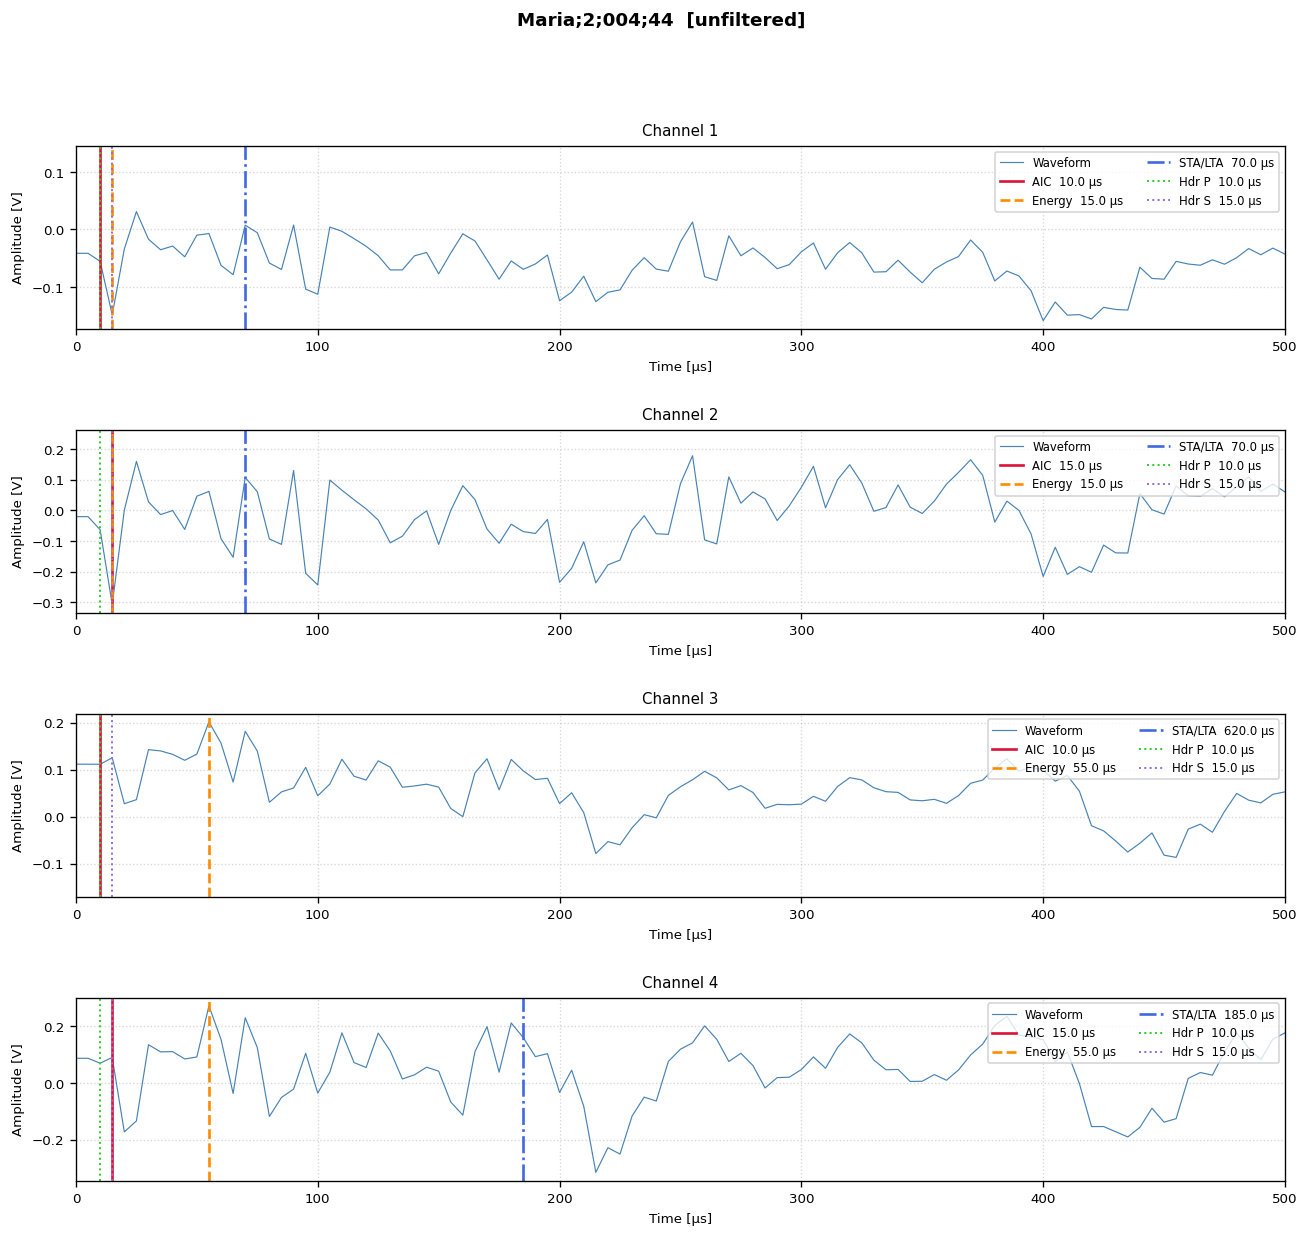

In [5]:
# ── Plot — all three pickers overlaid ─────────────────────────────────────
fig = plot_channels(
    meta, channels,
    picks={
        "AIC":     aic_picks,
        "Energy":  energy_picks,
        "STA/LTA": stalta_picks,
    },
    signal_type="unfiltered",
    zoom_us=500,          # show only the first 500 µs
    savepath=OUTPUT_DIR / (demo_file.stem + "_algo_comparison.png"),
)
plt.show()

### 4b  Filtered file — AIC on centred record

  AIC pick: 10.00 µs
  AIC pick: 16.00 µs


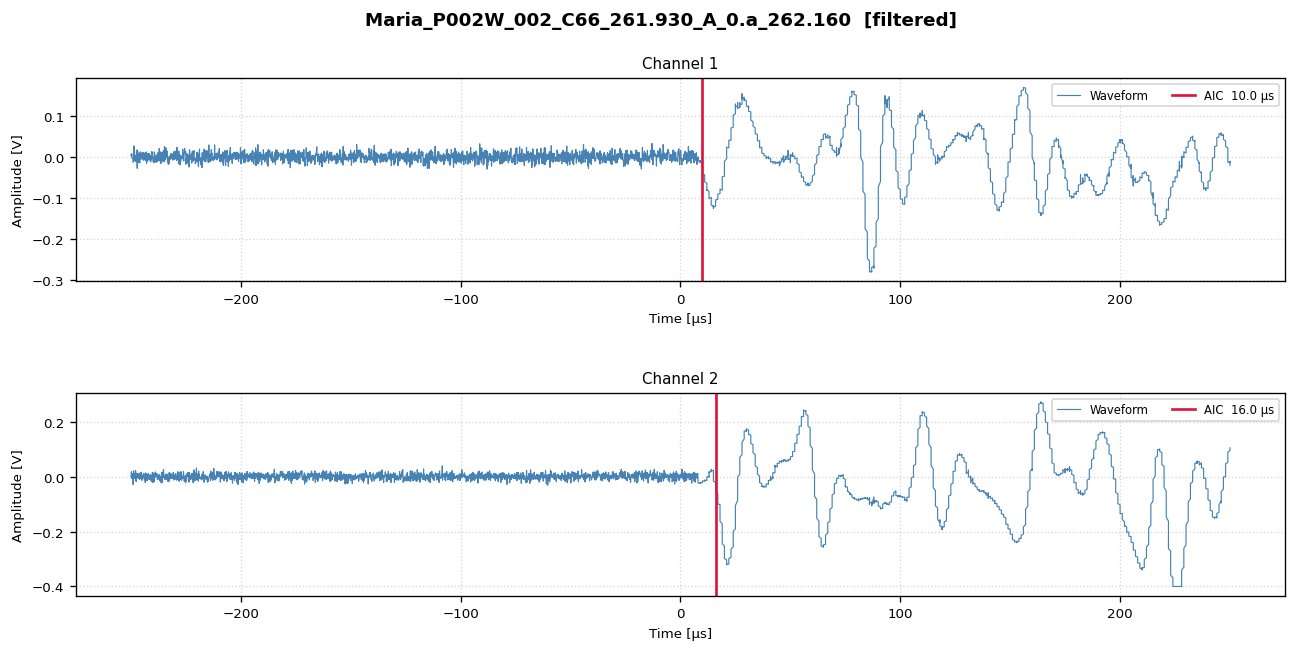

In [6]:
meta_f, ch_f = read_filtered(filtered_files[0])
N_f = len(ch_f[0]["time"])

# Search the central 40 % — arrival is near t = 0
aic_picks_f = []
for ch in ch_f:
    idx, _ = aic_picker(ch["amp"],
                        search_start=int(0.30 * N_f),
                        search_end=int(0.70 * N_f))
    aic_picks_f.append(idx)
    print(f"  AIC pick: {ch['time'][idx]*1e6:.2f} µs")

fig = plot_channels(meta_f, ch_f,
                    picks={"AIC": aic_picks_f},
                    signal_type="filtered")
plt.show()

## 5  Batch-process all files


=== unfiltered_signals [unfiltered] (5 files) ===
  Maria_P002W_004_C44_231.000_A_0.a_231.046.txt


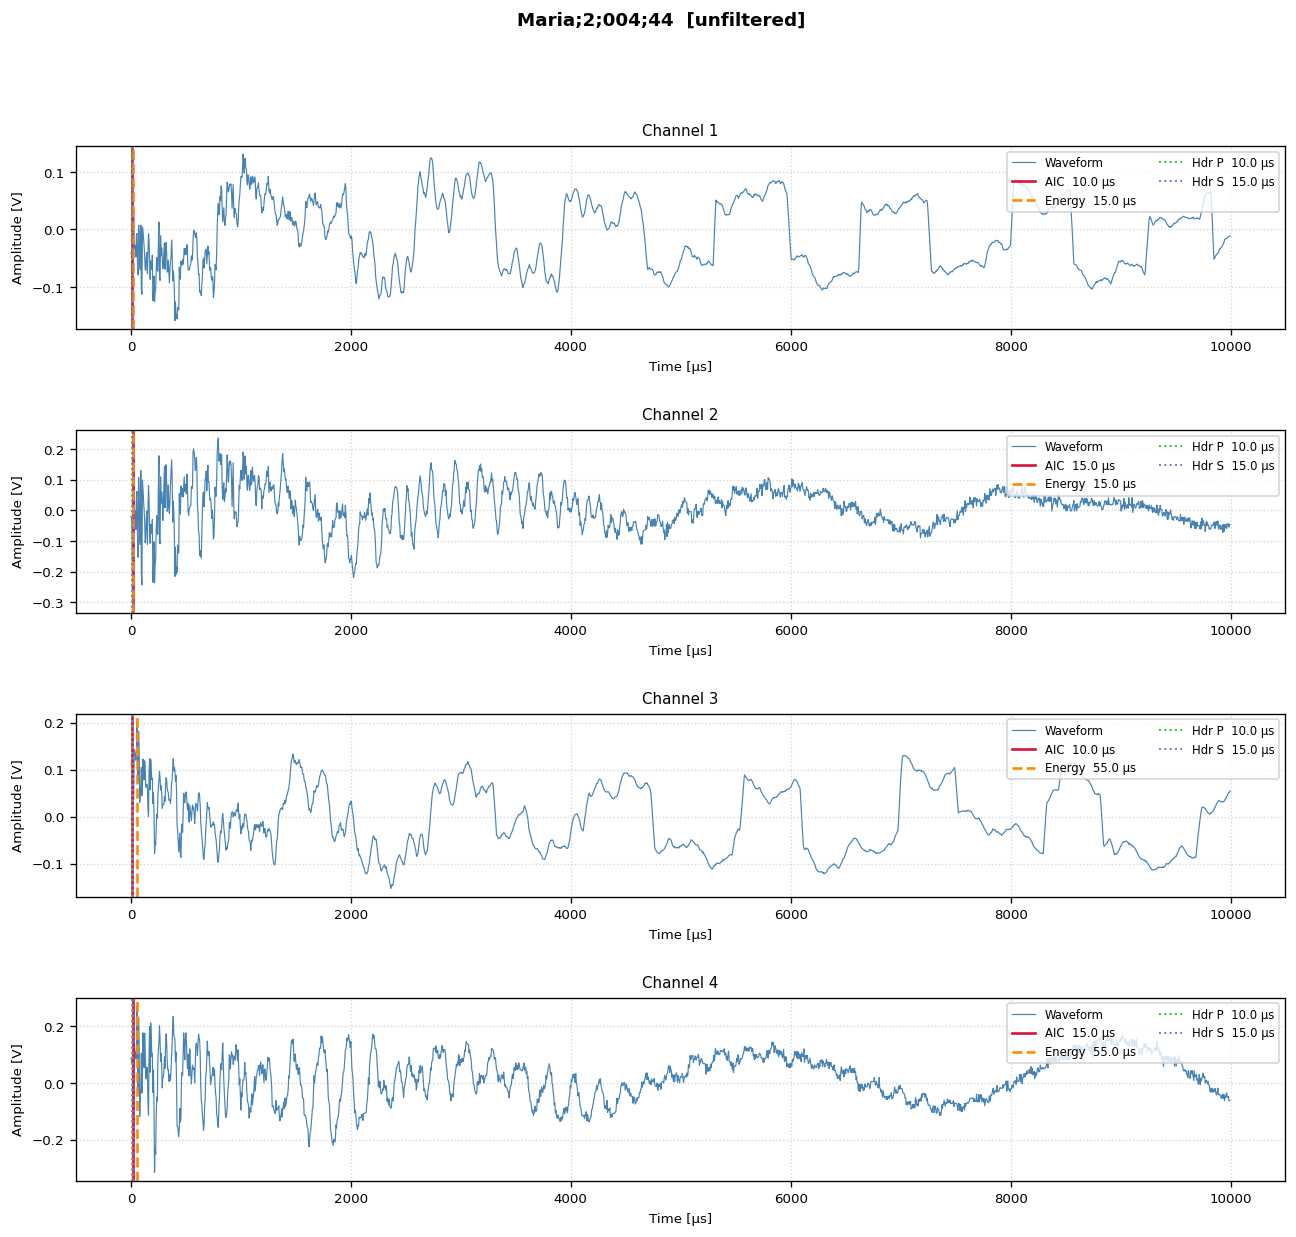

  Maria_P002W_004_C78_203.200_A_0.a_203.560.txt


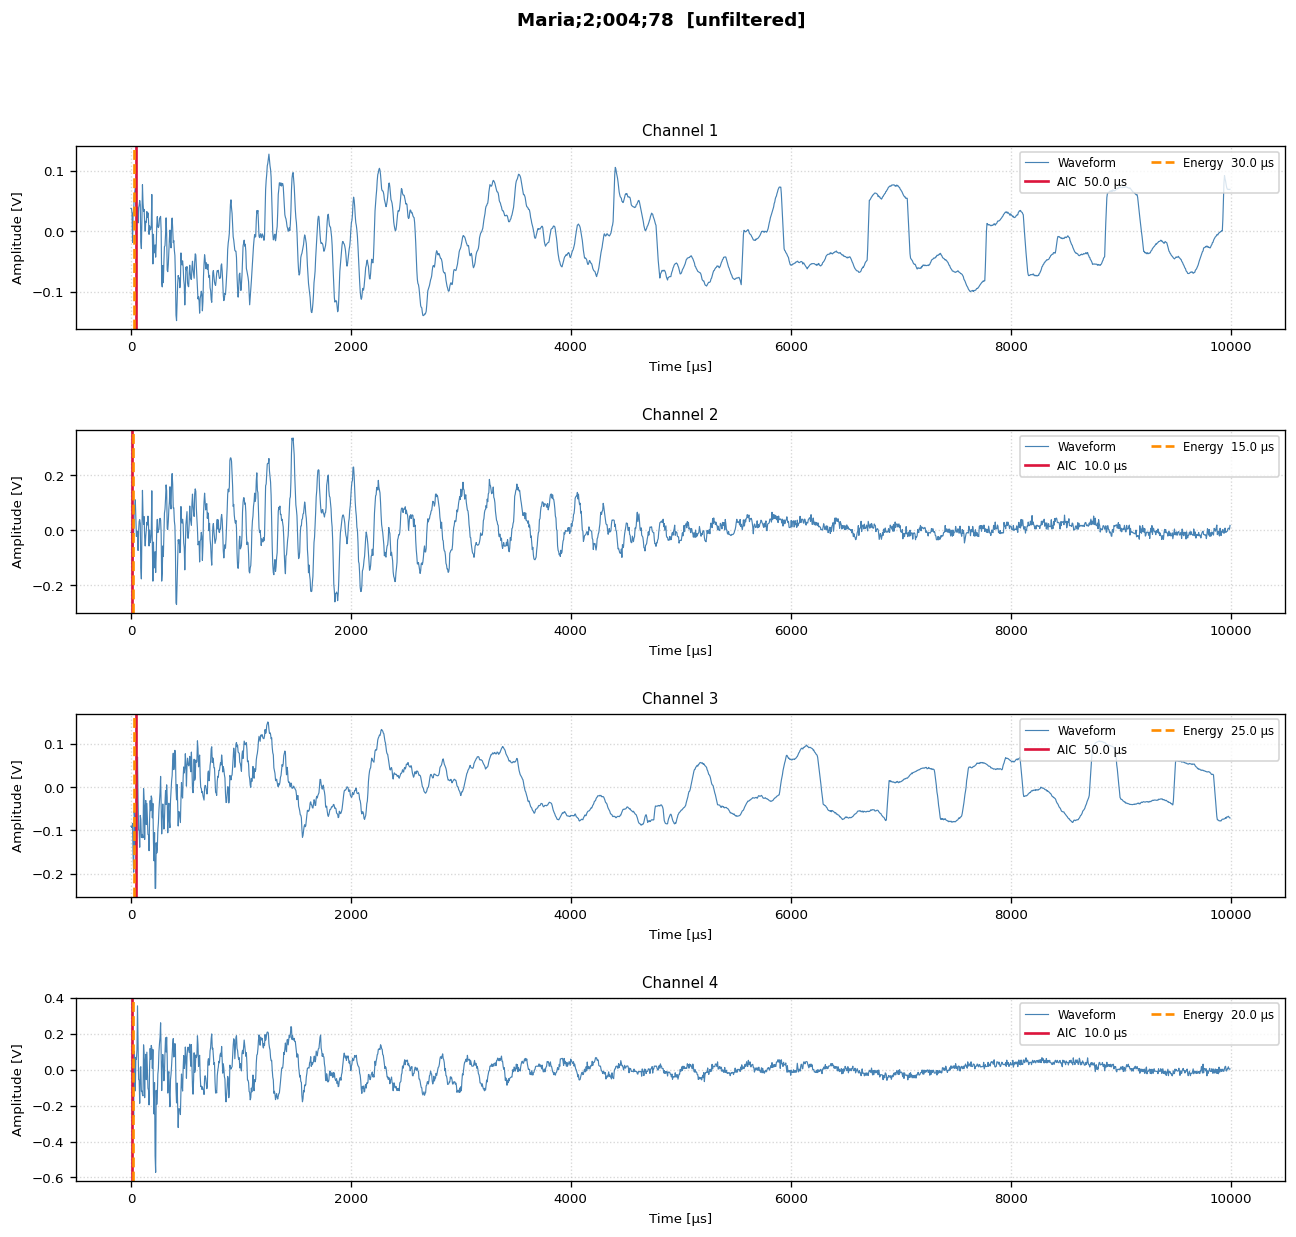

  Maria_P002W_004_C98_185.190_A_3.a_185.810.txt


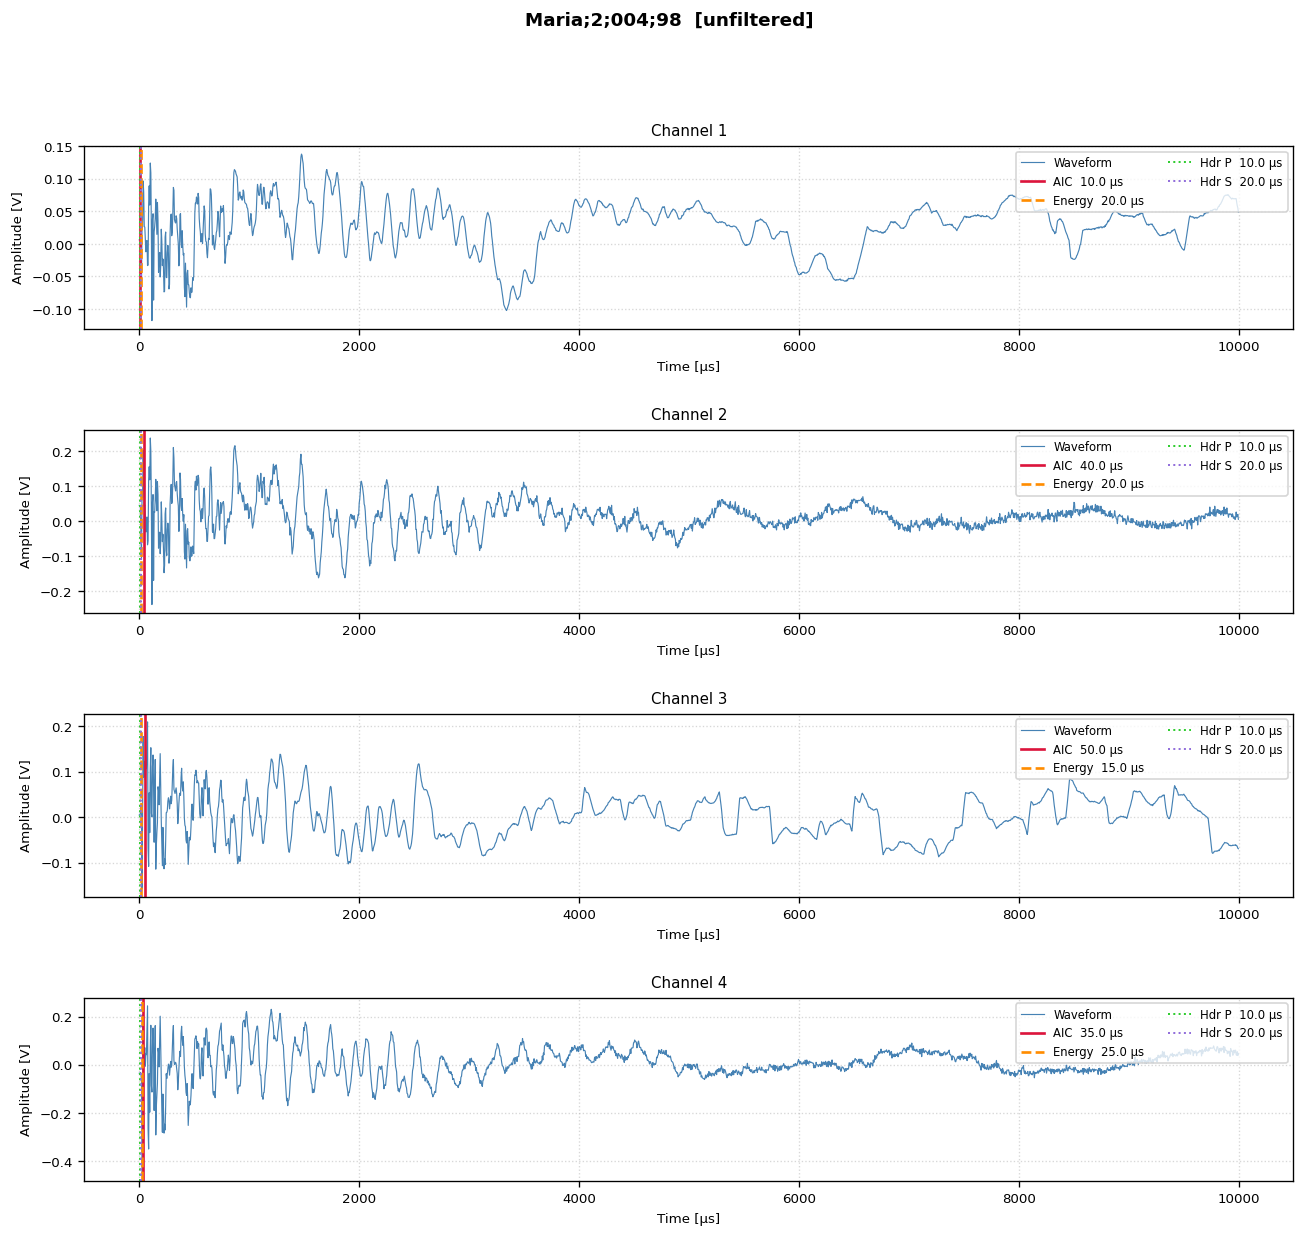

  Maria_P002W_005_C01_183.720_A_0.a_183.850.txt


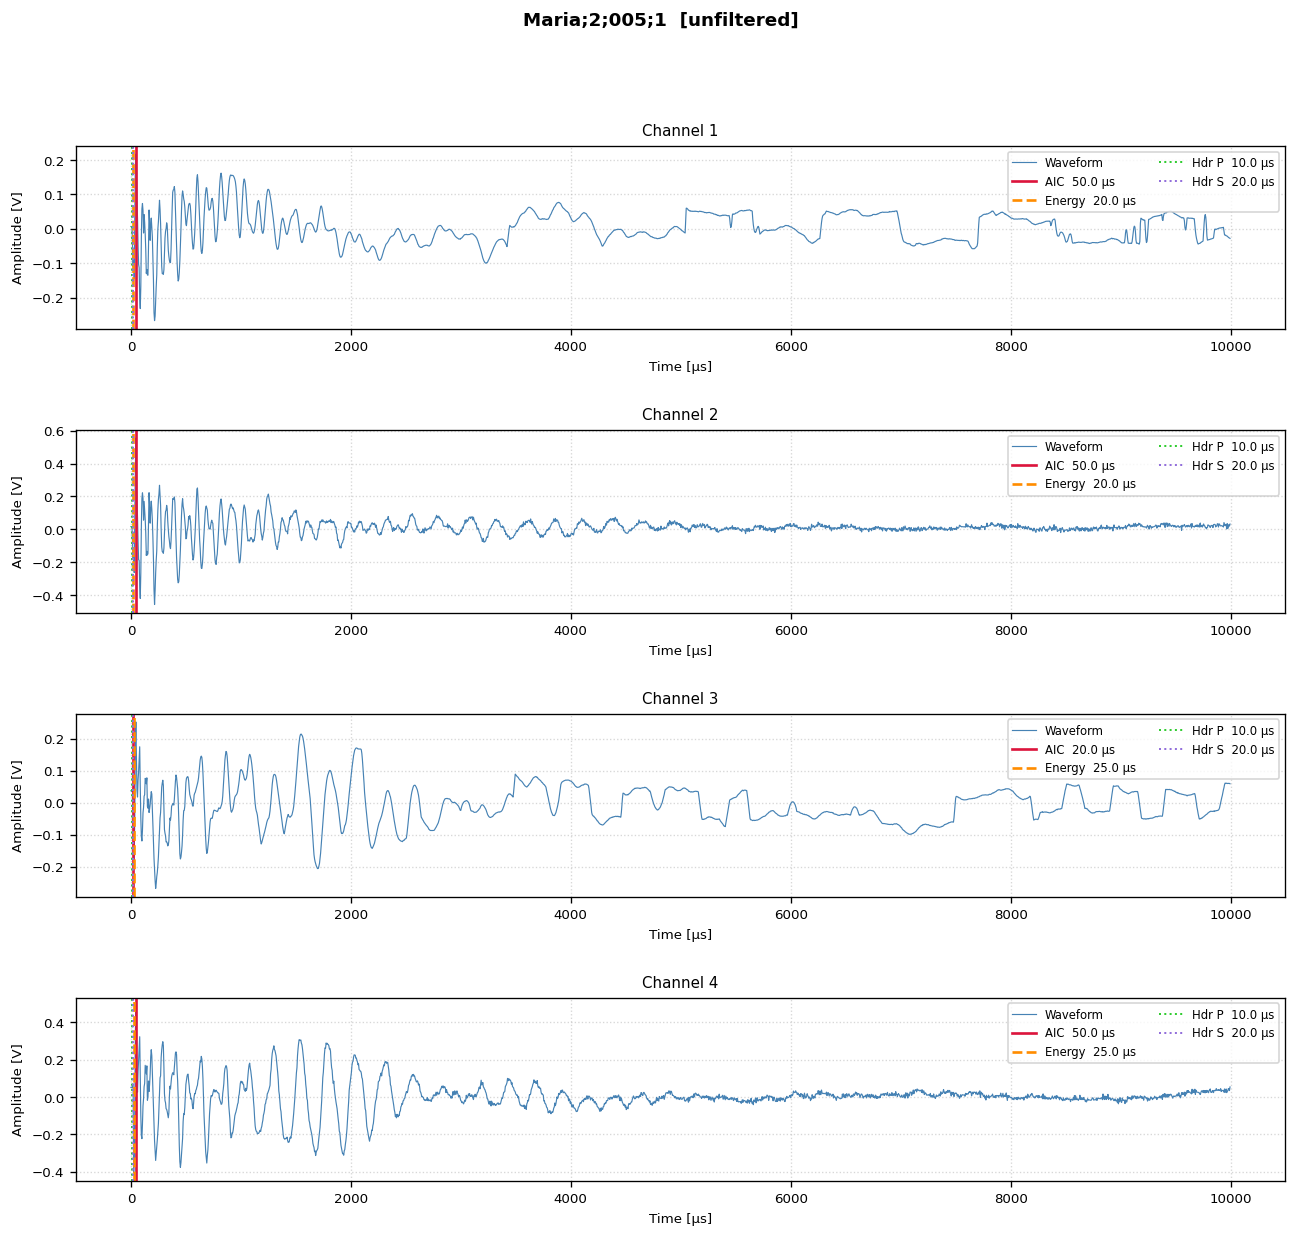

  Maria_P002W_005_C06_182.450_A_0.a_182.760.txt


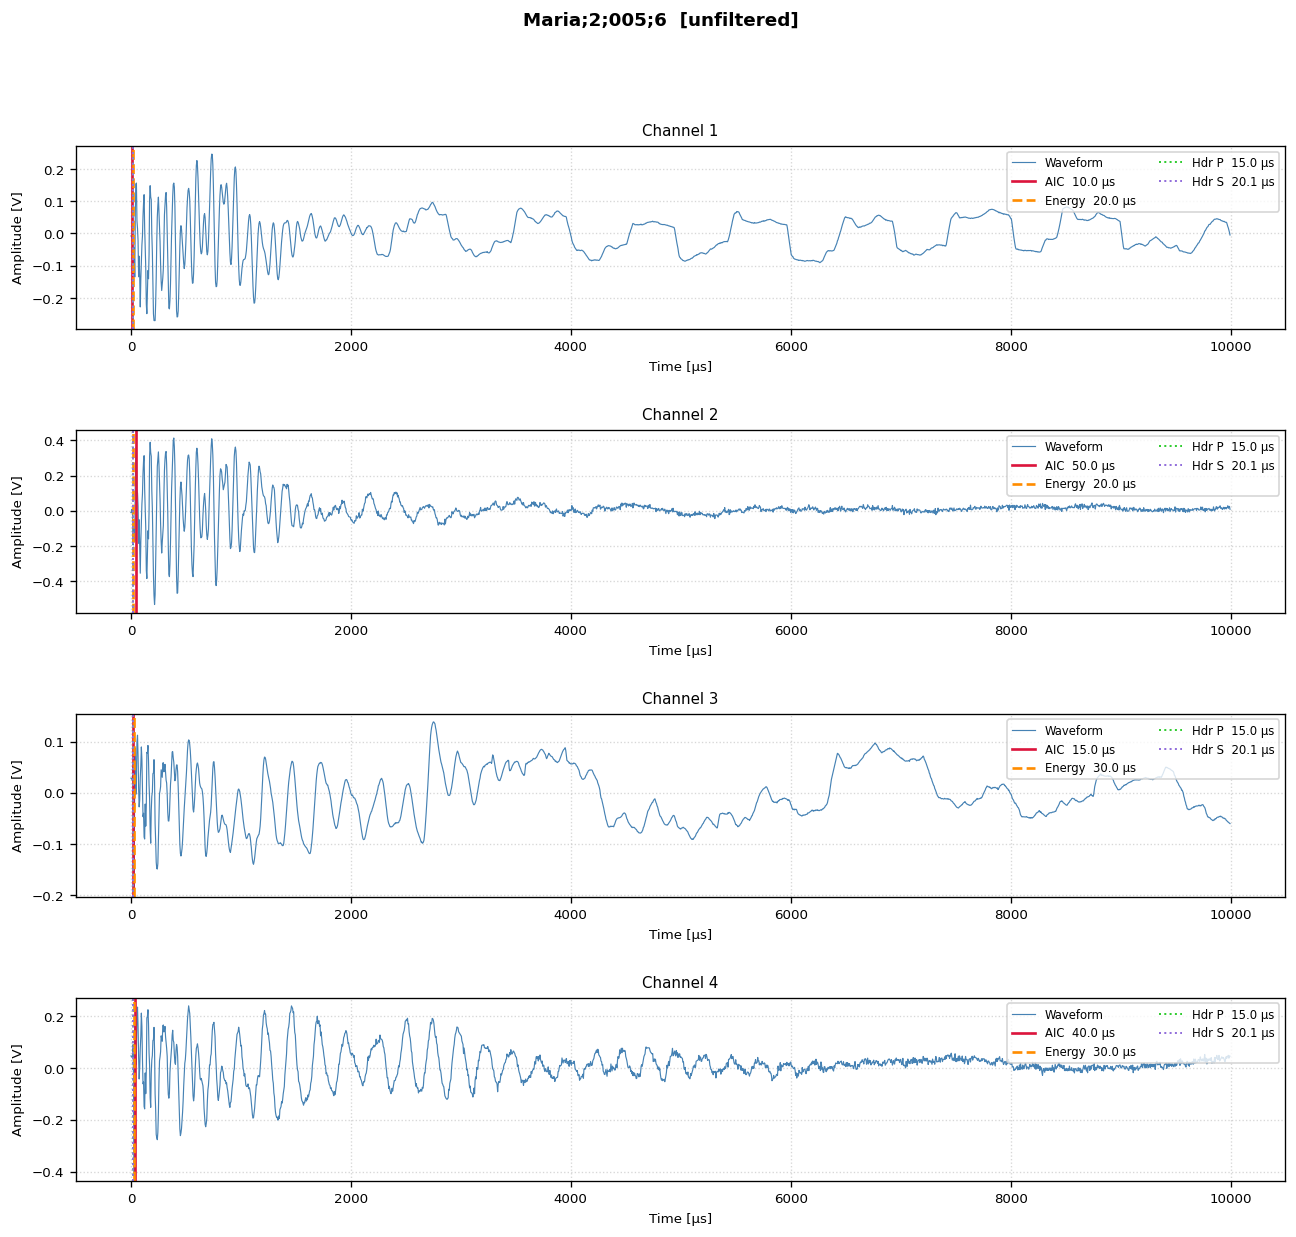


=== filtered_signals [filtered] (5 files) ===
  Maria_P002W_002_C66_261.930_A_0.a_262.160.txt


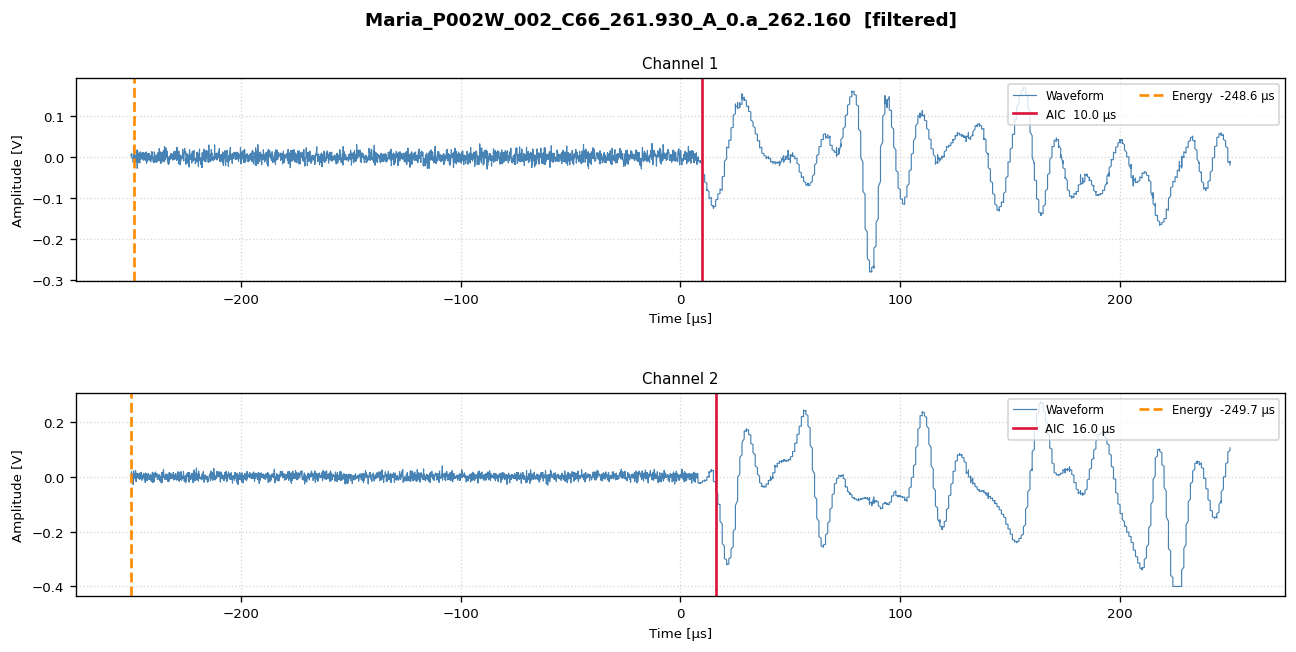

  Maria_P002W_003_C01_291.960_A_0.a_292.140.txt


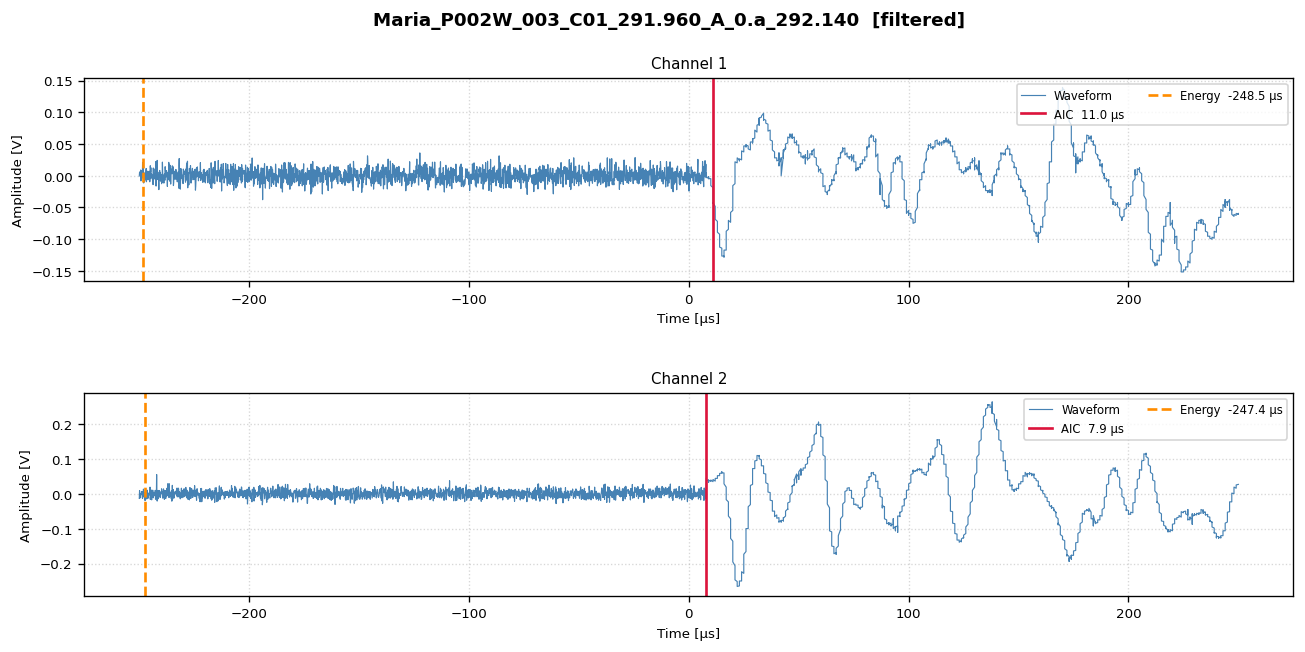

  Maria_P002W_003_C81_339.980_A_0.a_340.040.txt


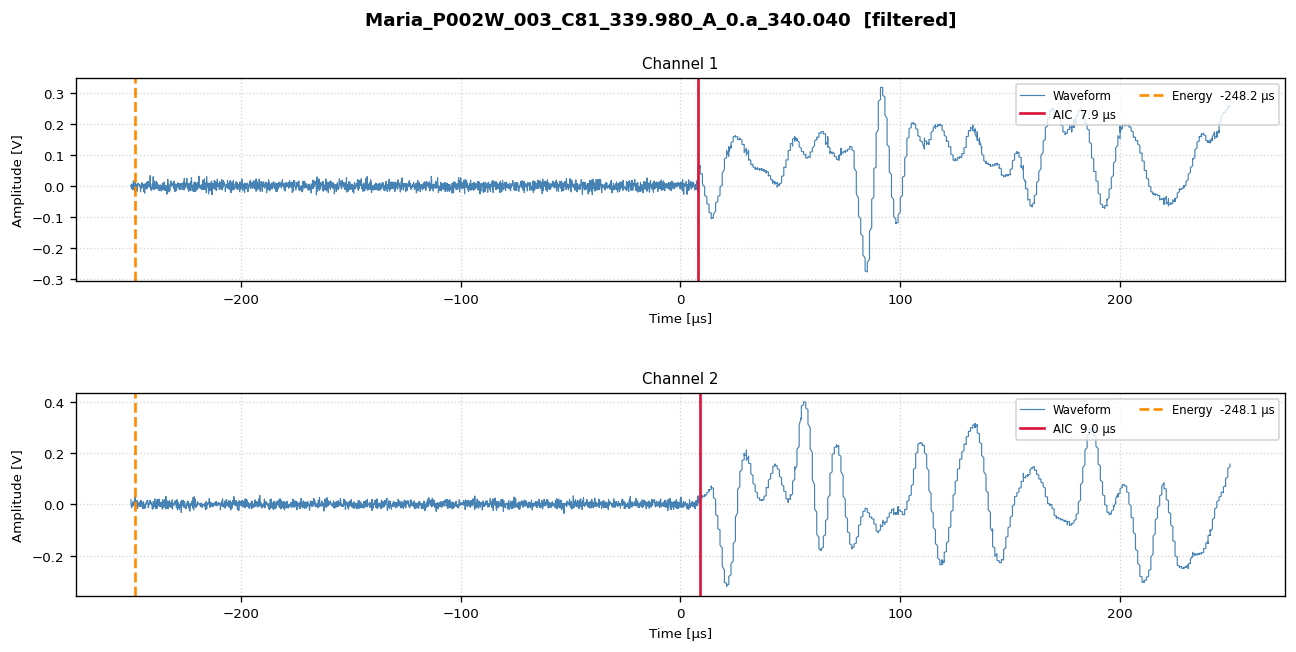

  Maria_P002W_004_C07_356.153_A_2.a_356.873.txt


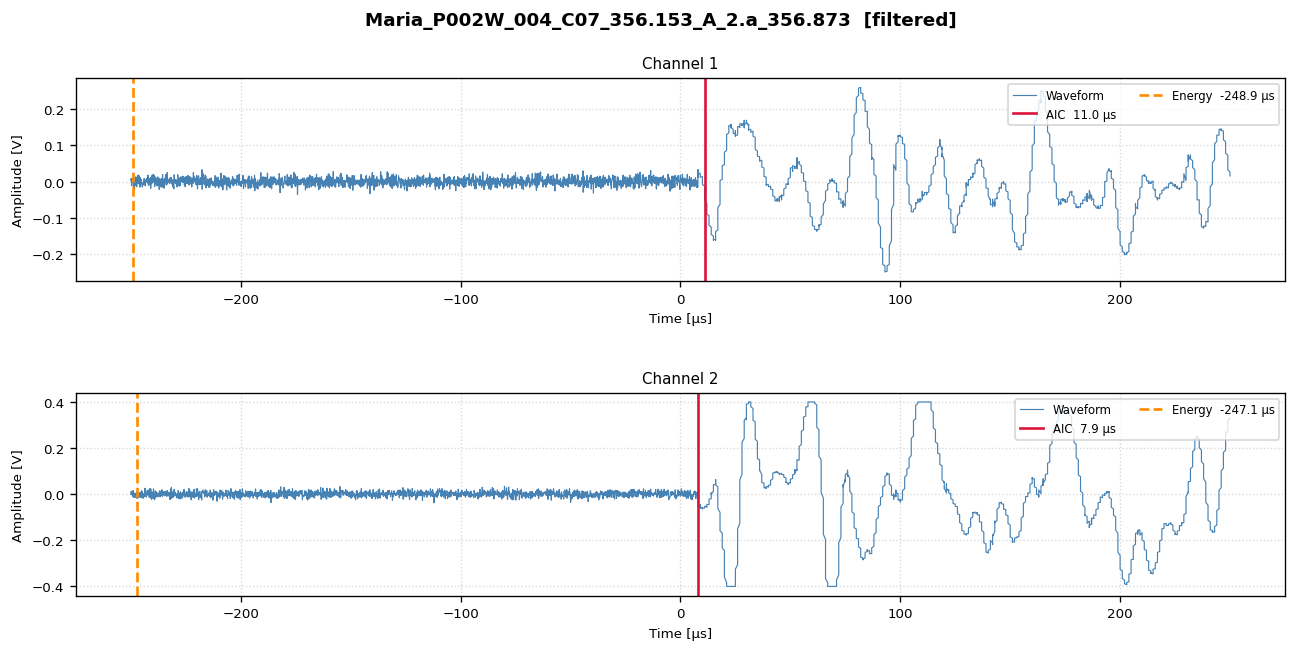

  Maria_P002W_004_C39_239.300_A_0.a_239.500.txt


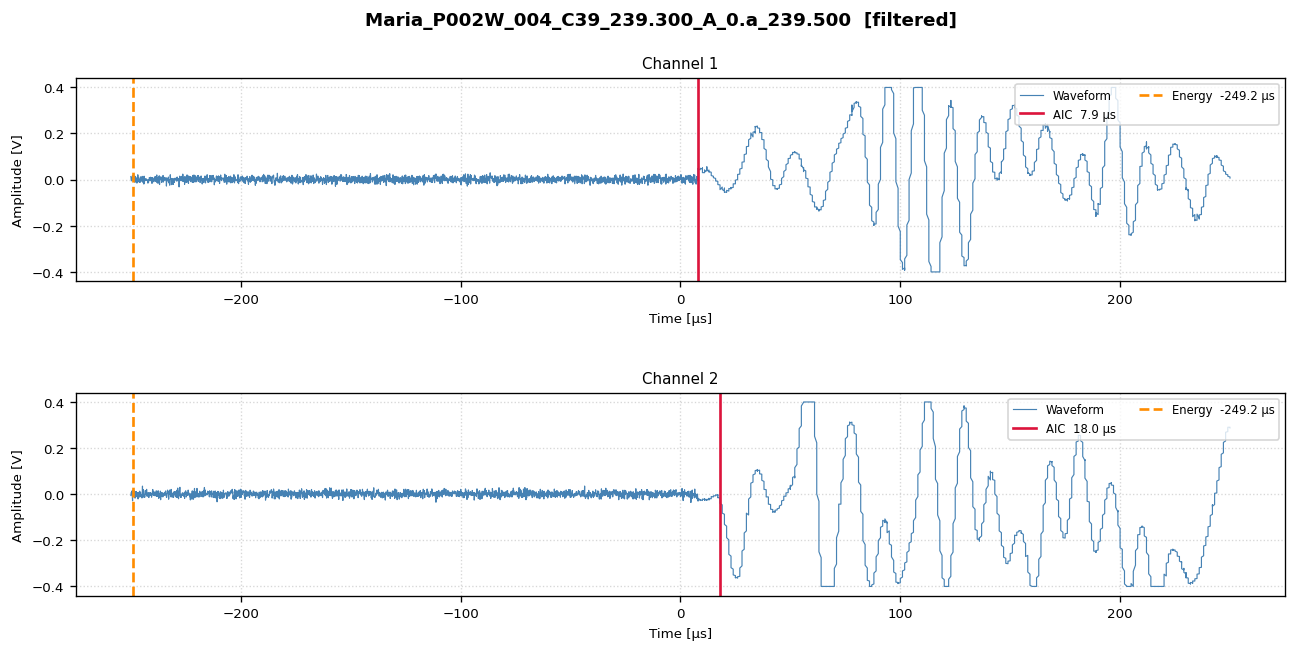


Summary saved: ..\picks_output\picks_summary.csv


In [7]:
df = run(
    data_dir    = DATA_DIR,
    output_dir  = OUTPUT_DIR,
    pickers     = ("aic", "energy"),   # also supports 'stalta'
    plot        = True,
    save_plots  = True,
)

## 6  Summary table & CSV export

In [8]:
display_cols = ["file", "signal_type", "channel",
                "aic_pick_us", "energy_pick_us",
                "header_P_s"]

df_display = df[display_cols].copy()
df_display["header_P_us"] = df_display["header_P_s"] * 1e6
df_display = df_display.drop(columns=["header_P_s"])

# Round µs columns to 2 decimal places
for col in ["aic_pick_us", "energy_pick_us", "header_P_us"]:
    df_display[col] = df_display[col].round(2)

df_display

,file,signal_type,channel,aic_pick_us,energy_pick_us,header_P_us
0,Maria_P002W_004_C44_231.000_A_0.a_231.046.txt,unfiltered,1,10.00,15.00,9.95
1,Maria_P002W_004_C44_231.000_A_0.a_231.046.txt,unfiltered,2,15.00,15.00,9.95
2,Maria_P002W_004_C44_231.000_A_0.a_231.046.txt,unfiltered,3,10.00,55.00,9.95
3,Maria_P002W_004_C44_231.000_A_0.a_231.046.txt,unfiltered,4,15.00,55.00,9.95
4,Maria_P002W_004_C78_203.200_A_0.a_203.560.txt,unfiltered,1,50.00,30.00,NaN
5,Maria_P002W_004_C78_203.200_A_0.a_203.560.txt,unfiltered,2,10.00,15.00,NaN
6,Maria_P002W_004_C78_203.200_A_0.a_203.560.txt,unfiltered,3,50.00,25.00,NaN
7,Maria_P002W_004_C78_203.200_A_0.a_203.560.txt,unfiltered,4,10.00,20.00,NaN
8,Maria_P002W_004_C98_185.190_A_3.a_185.810.txt,unfiltered,1,10.00,20.00,10.00
9,Maria_P002W_004_C98_185.190_A_3.a_185.810.txt,unfiltered,2,40.00,20.00,10.00


In [9]:
csv_path = OUTPUT_DIR / "picks_summary.csv"
df.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

Saved: ..\picks_output\picks_summary.csv


## 7  Compare computed picks against reference header picks

For unfiltered files the P-wave arrival time stored in the file header serves
as a reference.  The scatter plot and residual chart below show how well AIC
and energy-onset agree with this reference.

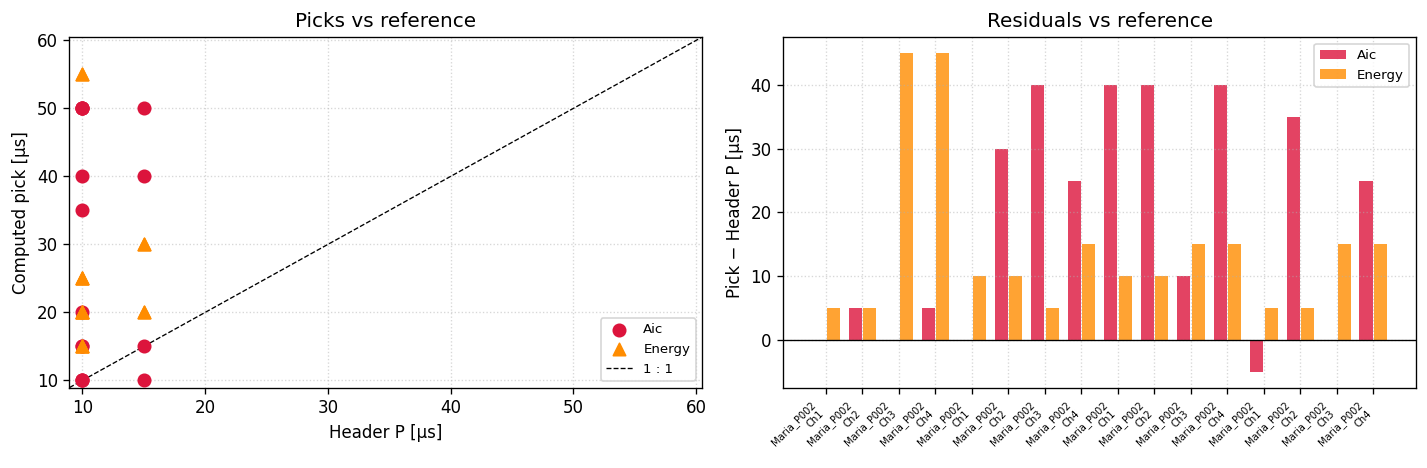

In [10]:
# Add a header_P_us column from the raw seconds column
df_cmp = df.copy()
df_cmp["header_P_us"] = df_cmp["header_P_s"] * 1e6

fig = plot_comparison(
    df_cmp,
    ref_col   = "header_P_us",
    pick_cols = ("aic_pick_us", "energy_pick_us"),
    savepath  = OUTPUT_DIR / "pick_comparison.png",
)
plt.show()

## 8  Onset zoom browser

Visual QC: shows the first 200 µs of each unfiltered record with AIC and
energy-onset picks overlaid side-by-side across all four channels.

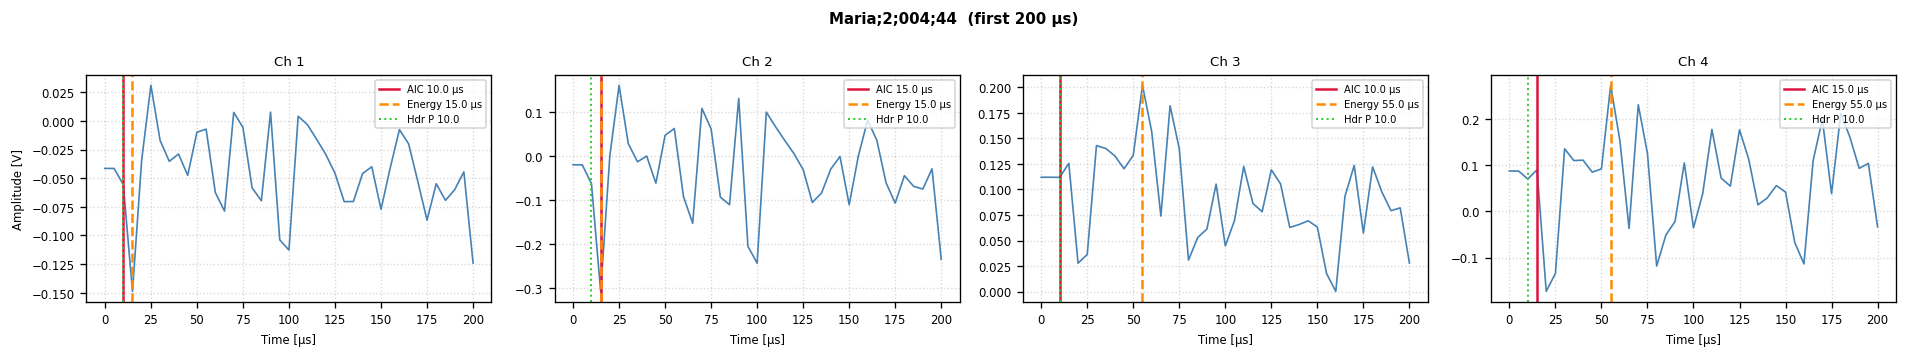

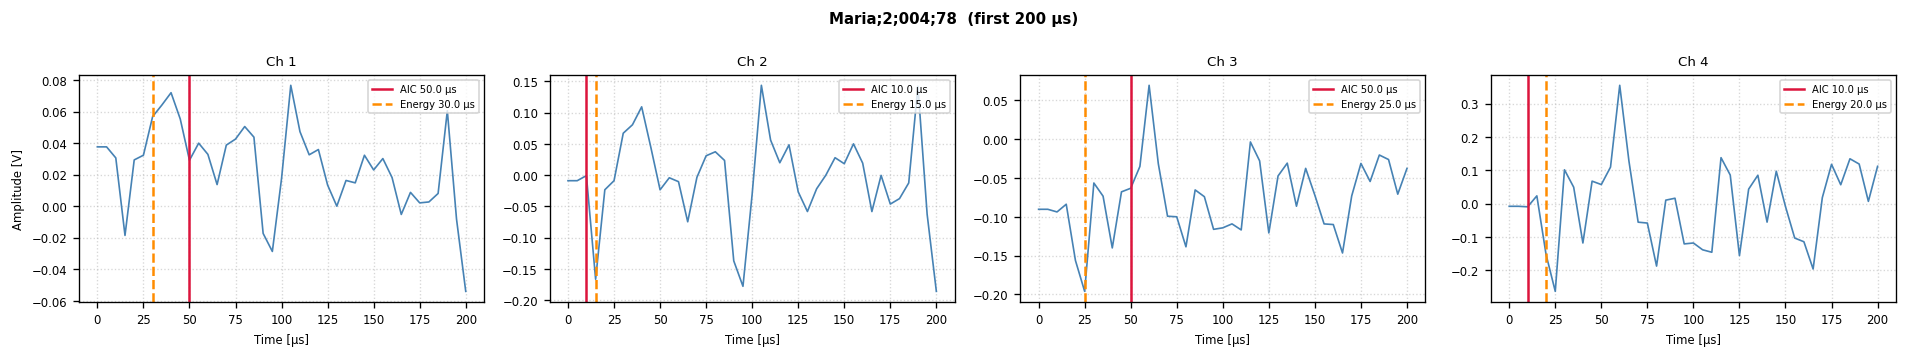

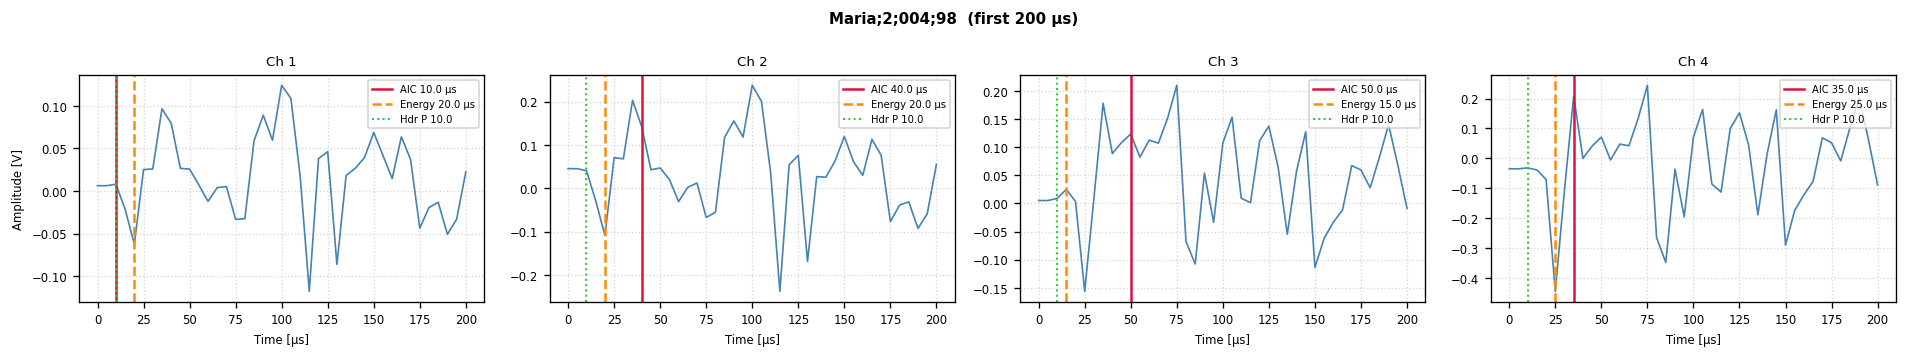

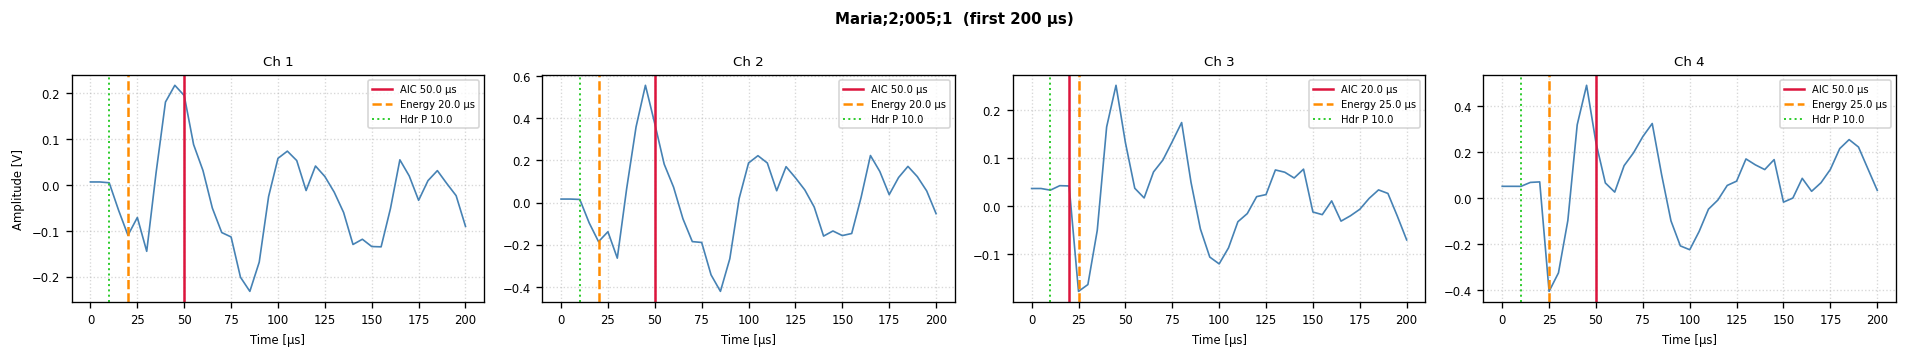

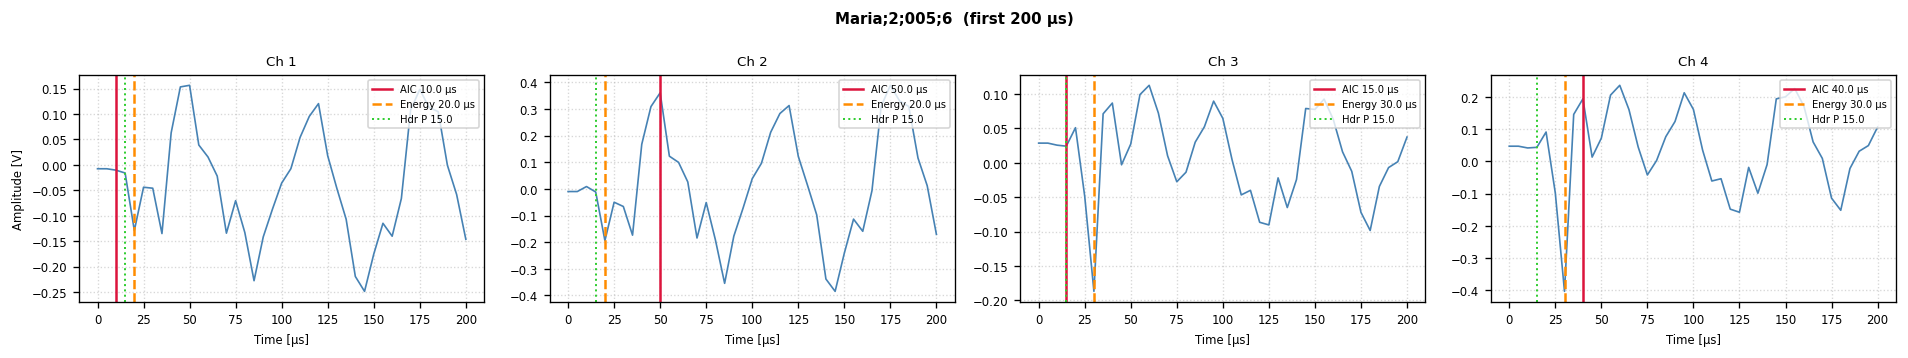

In [11]:
figures = plot_onset_zoom(
    files            = unfiltered_files,
    reader_fn        = read_unfiltered,
    zoom_us          = 200,
    noise_window_s   = 25e-6,
    energy_threshold = 3.0,
    aic_search_end   = 10,
    savepath_dir     = OUTPUT_DIR,
)
for fig in figures:
    plt.show()
    plt.close(fig)